# 04b - Clustering Evaluation
Vizualizace a interpretace shluku pro oba algoritmy (K-Means + Agglomerative). Tento notebook **nic netrenuuje**.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

plt.style.use('dark_background')
sns.set_palette("viridis")

# Nacteni vystupu z 041
payload             = joblib.load('../data/processed/clustered_data.pkl')
X_cluster           = payload['X_cluster']
cols_for_clustering = payload['cols_for_clustering']
OPTIMAL_K           = payload['OPTIMAL_K']

kmeans_final = joblib.load('../models/kmeans_final.pkl')
pca          = joblib.load('../models/pca_2d.pkl')

print(f"Nacteno: {len(X_cluster)} zaznamu, {OPTIMAL_K} shluku")
print(f"Sloupce: {cols_for_clustering}")

Nacteno: 10000 zaznamu, 3 shluku
Sloupce: ['Stress_Index', 'Study_Hours_per_Day', 'Family_Income', 'CGPA']


## PCA scatter plot — vizualizace shluku ve 2D

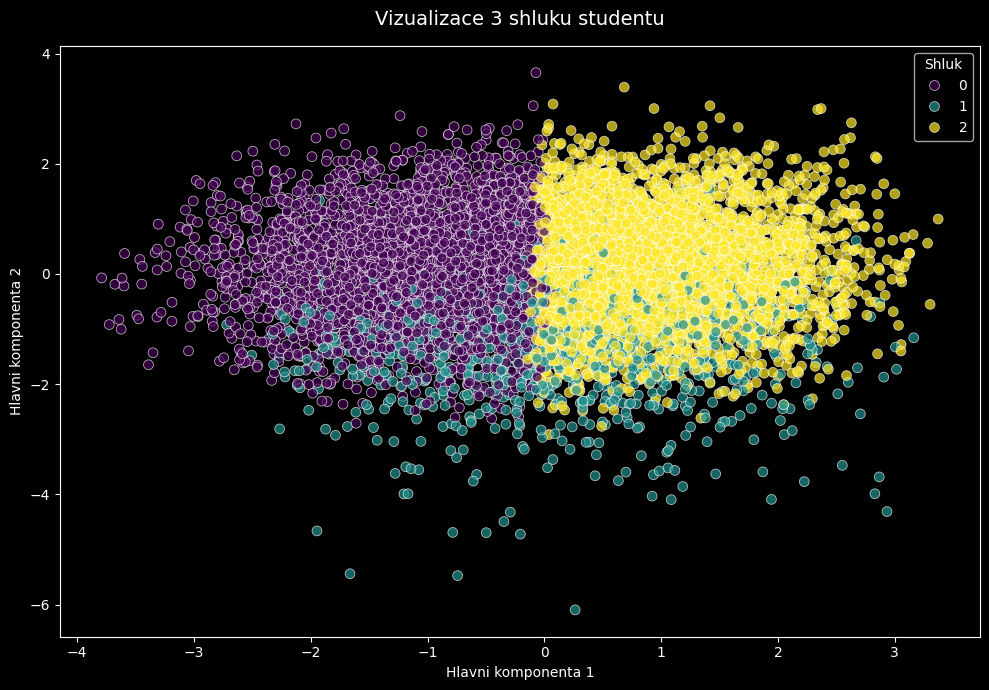

In [2]:
components = pca.transform(X_cluster[cols_for_clustering])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=components[:, 0], y=components[:, 1],
    hue=X_cluster['Cluster'],
    palette='viridis',
    alpha=0.7,
    s=50
)
plt.title(f'Vizualizace {OPTIMAL_K} shluku studentu', color='white', fontsize=14, pad=15)
plt.xlabel('Hlavni komponenta 1', color='white')
plt.ylabel('Hlavni komponenta 2', color='white')
plt.legend(title='Shluk')
plt.tight_layout()
plt.show()

## Rozlozeni priznaku podle shluku (boxploty)

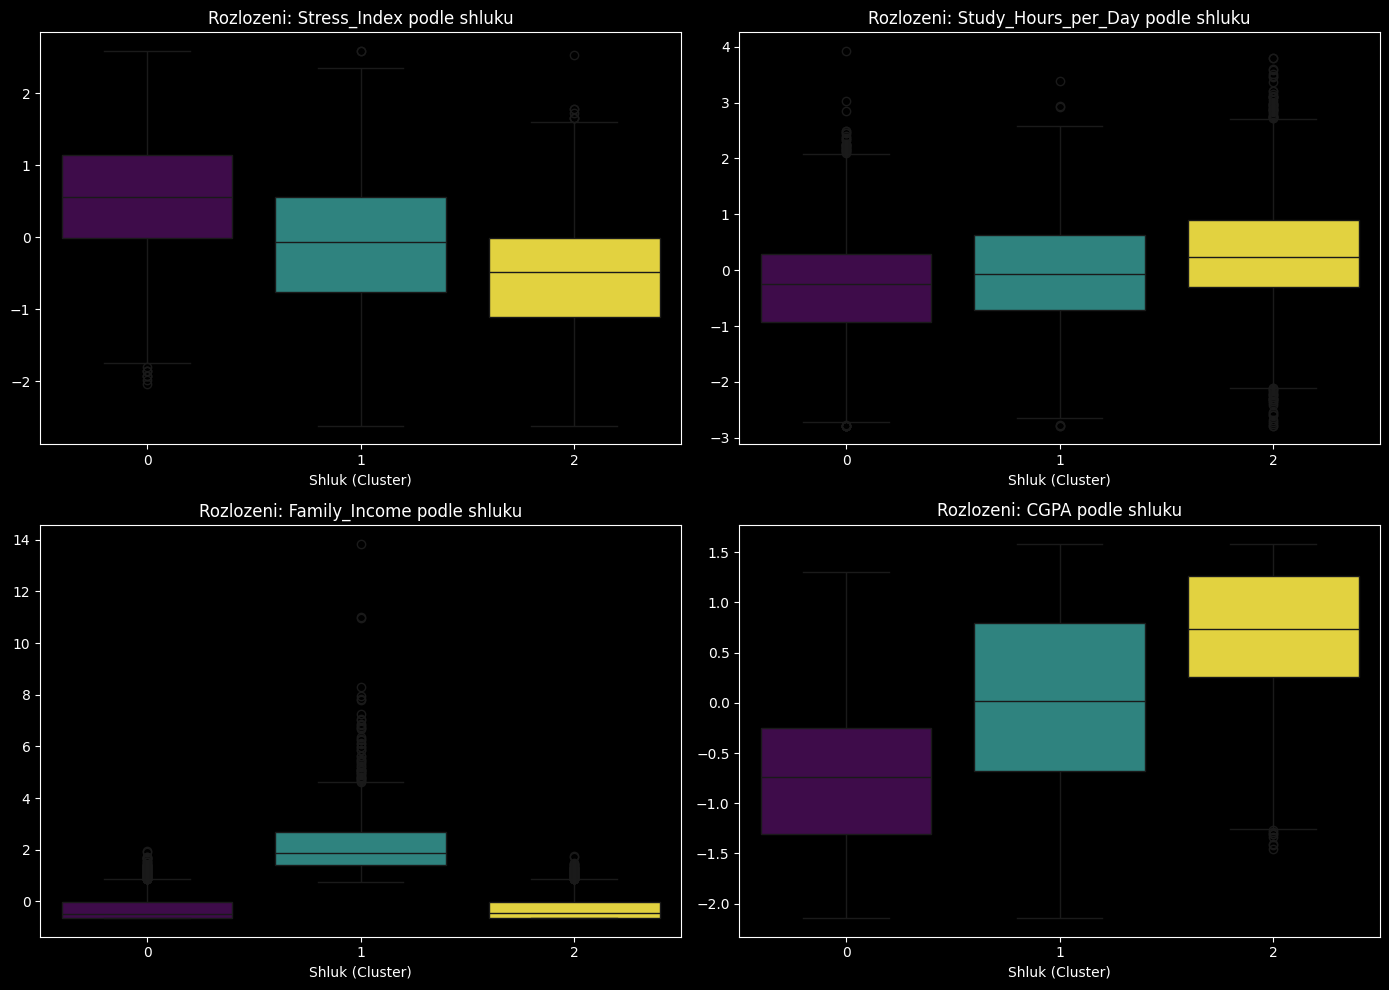

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_for_clustering):
    sns.boxplot(
        data=X_cluster, x='Cluster', y=col,
        hue='Cluster', ax=axes[i],
        palette='viridis', legend=False
    )
    axes[i].set_title(f'Rozlozeni: {col} podle shluku', color='white', fontsize=12)
    axes[i].tick_params(colors='white')
    axes[i].set_xlabel('Shluk (Cluster)', color='white')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## Prumerne hodnoty per shluk (cluster profiles)

In [4]:
cluster_profiles = X_cluster.groupby('Cluster')[cols_for_clustering + ['Dropout']].mean()

print("--- Prumerne hodnoty pro kazdy shluk ---")
print(cluster_profiles.round(3).to_string())

--- Prumerne hodnoty pro kazdy shluk ---
         Stress_Index  Study_Hours_per_Day  Family_Income   CGPA  Dropout
Cluster                                                                  
0               0.587               -0.304         -0.273 -0.769    0.400
1              -0.109               -0.031          2.228  0.027    0.211
2              -0.538                0.287         -0.273  0.712    0.088


## Dropout rate per shluk

In [5]:
dropout_rate = X_cluster.groupby('Cluster')['Dropout'].agg(['mean', 'count', 'sum'])
dropout_rate.columns = ['Dropout_Rate', 'Celkem_Studentu', 'Pocet_Dropout']
dropout_rate['Dropout_Rate'] = dropout_rate['Dropout_Rate'].map('{:.1%}'.format)

print("--- Dropout rate per shluk ---")
print(dropout_rate.to_string())

--- Dropout rate per shluk ---
        Dropout_Rate  Celkem_Studentu  Pocet_Dropout
Cluster                                             
0              40.0%             4298           1718
1              21.1%             1103            233
2               8.8%             4599            403


## Agglomerative vs. K-Means — porovnání
Vizualizujeme shluky obou algoritmu ve stejnem 2D PCA prostoru pro primy vizualni srovnani.

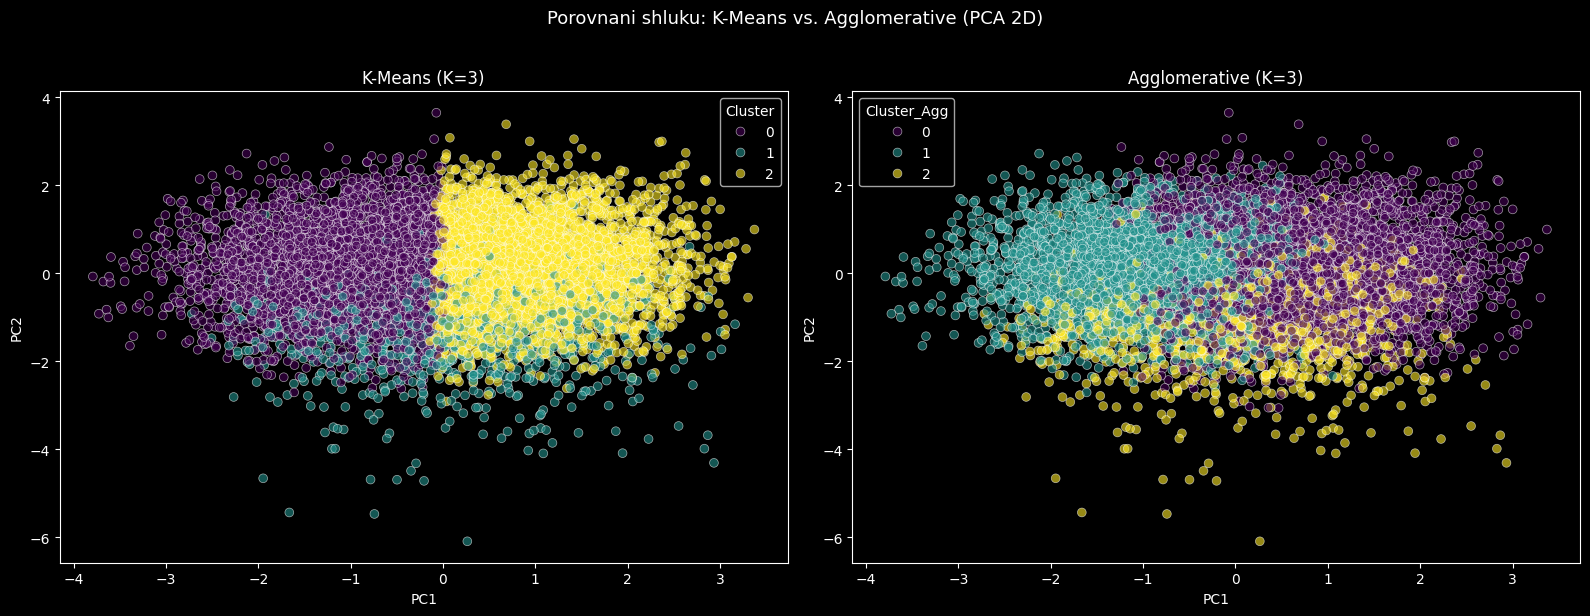


--- Dropout rate: K-Means vs. Agglomerative ---

K-Means:
        Dropout_Rate     N
Cluster                   
0              40.0%  4298
1              21.1%  1103
2               8.8%  4599

Agglomerative:
            Dropout_Rate     N
Cluster_Agg                   
0                  10.8%  4511
1                  38.3%  4031
2                  22.2%  1458


In [6]:
if 'Cluster_Agg' not in X_cluster.columns:
    print("VAROVANI: Cluster_Agg neni v datech — spust znovu 041 s Agglomerative sekcí.")
else:
    components = pca.transform(X_cluster[cols_for_clustering])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, col, title in [
        (axes[0], 'Cluster',     f'K-Means (K={X_cluster["Cluster"].nunique()})'),
        (axes[1], 'Cluster_Agg', f'Agglomerative (K={X_cluster["Cluster_Agg"].nunique()})'),
    ]:
        import seaborn as sns
        sns.scatterplot(
            x=components[:, 0], y=components[:, 1],
            hue=X_cluster[col], palette='viridis', alpha=0.6, s=40, ax=ax
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')

    fig.suptitle('Porovnani shluku: K-Means vs. Agglomerative (PCA 2D)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Srovnavaci tabulka dropout rate
    print("\n--- Dropout rate: K-Means vs. Agglomerative ---")
    for col, label in [('Cluster', 'K-Means'), ('Cluster_Agg', 'Agglomerative')]:
        dr = X_cluster.groupby(col)['Dropout'].agg(['mean','count'])
        dr.columns = ['Dropout_Rate', 'N']
        dr['Dropout_Rate'] = dr['Dropout_Rate'].map('{:.1%}'.format)
        print(f"\n{label}:")
        print(dr.to_string())

## Ulozeni cluster profiles

In [7]:
os.makedirs('../results', exist_ok=True)

cluster_profiles.round(4).to_csv('../results/cluster_profiles.csv')
print("  results/cluster_profiles.csv")

  results/cluster_profiles.csv
